# **Pre-Processing**

**Import Dataset**

In [1]:
import pandas as pd

df = pd.read_csv("Dataset/livinMandiri_reviews_translated.csv")
df

,at,content,content_translated
0,2025-09-21 04:02:38,sangat ok aplikasi ini,this application is very good
1,2025-09-21 03:31:28,mandiri yg terbaik,the best independent
2,2025-09-21 03:24:19,aplikasi lemot dan ribet,the application is slow and complicated
3,2025-09-21 03:16:41,"Semoga lebih di permudah,sukses terus livin","Hopefully it will be easier, continued success..."
4,2025-09-21 03:14:06,sedih bgt kl sering minta update. hp mekori su...,It's really sad when you frequently ask for up...
...,...,...,...
99995,2023-08-21 05:43:31,Mantap 👍,Great 👍
99996,2023-08-21 05:40:08,(Pppp(kokolaverz koll lkklkkl klip kkkkkklkkk,(Pppp(kokolaverz koll lkklkkl klip kkkkkklkkk
99997,2023-08-21 05:37:51,Mantap,Excellent
99998,2023-08-21 05:37:45,Kepana sekarang mau transfer gagal terus,Why do transfers keep failing now?


**Slang Words Normalization & Text Cleaning**

In [2]:
pip install contractions

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
slang_dict = {
    "mandiri bank": "bank",
    "bank mandiri": "bank",
    "livin by mandiri": "app",
    "livin mandiri": "app",
    "log in": "login",
    "log on": "login",
    "log out": "logout",
    "top up": "topup",

    "tf": "transfer",
    "apk": "app",
    "application": "app",
    "cs": "customer service",
    "acc": "accepted",
    "mantul": "excellent",
    "e-wallet": "electronic wallet",
    "ewallet": "electronic wallet",
    "m-banking": "mobile banking",
    "mbanking": "mobile banking",
    "top-up": "topup",
    "mandiri": "bank",
    "independent": "bank",
    "livin": "app"
}

In [ ]:
import re
import contractions

def clean_text(text):
    if pd.isna(text):
        return ""
    
    text = str(text).lower()
    for slang, formal in slang_dict.items():
        text = re.sub(r'\b' + slang + r'\b', formal, text)
    text = re.sub(r'\b(\w+)(?:\s+\1\b)+', r'\1', text)    # Remove repeated words
    text = contractions.fix(text)                         # Expand contractions 
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)   # Remove URL
    text = re.sub(r'@\w+|#\w+', '', text)                 # Remove mentions & hashtags
    text = re.sub(r'[^a-z\s]', ' ', text)                 # Remove numbers, punctuation, and emojis
    text = re.sub(r'\s+', ' ', text).strip()              # Remove extra spaces
    return text

df['cleaned'] = df['content_translated'].apply(clean_text)
df

,at,content,content_translated,cleaned
0,2025-09-21 04:02:38,sangat ok aplikasi ini,this application is very good,this app is very good
1,2025-09-21 03:31:28,mandiri yg terbaik,the best independent,the best bank
2,2025-09-21 03:24:19,aplikasi lemot dan ribet,the application is slow and complicated,the app is slow and complicated
3,2025-09-21 03:16:41,"Semoga lebih di permudah,sukses terus livin","Hopefully it will be easier, continued success...",hopefully it will be easier continued success app
4,2025-09-21 03:14:06,sedih bgt kl sering minta update. hp mekori su...,It's really sad when you frequently ask for up...,it is really sad when you frequently ask for u...
...,...,...,...,...
99995,2023-08-21 05:43:31,Mantap 👍,Great 👍,great
99996,2023-08-21 05:40:08,(Pppp(kokolaverz koll lkklkkl klip kkkkkklkkk,(Pppp(kokolaverz koll lkklkkl klip kkkkkklkkk,pppp kokolaverz koll lkklkkl klip kkkkkklkkk
99997,2023-08-21 05:37:51,Mantap,Excellent,excellent
99998,2023-08-21 05:37:45,Kepana sekarang mau transfer gagal terus,Why do transfers keep failing now?,why do transfers keep failing now


**Droping Empty Rows**

Many reviews contain only emojis, so after text cleaning, that column becomes empty.

In [5]:
emptyRow = len(df[df['cleaned'] == ""])
print(f"Number of empty rows (but not NaN): {emptyRow}")

Number of empty rows (but not NaN): 920


In [6]:
import numpy as np
df['cleaned'].replace("", np.nan, inplace=True)
df.dropna(subset=['cleaned'], inplace=True)
print("Number of rows after dropping null values:", len(df))

Number of rows after dropping null values: 99080


C:\Users\A.ANGGADIPA\AppData\Local\Temp\ipykernel_9660\2127933692.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['cleaned'].replace("", np.nan, inplace=True)


**Tokenize**

In [7]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\A.ANGGADIPA\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [8]:
from nltk.tokenize import word_tokenize

df['tokens'] = df['cleaned'].apply(word_tokenize)
df

,at,content,content_translated,cleaned,tokens
0,2025-09-21 04:02:38,sangat ok aplikasi ini,this application is very good,this app is very good,"[this, app, is, very, good]"
1,2025-09-21 03:31:28,mandiri yg terbaik,the best independent,the best bank,"[the, best, bank]"
2,2025-09-21 03:24:19,aplikasi lemot dan ribet,the application is slow and complicated,the app is slow and complicated,"[the, app, is, slow, and, complicated]"
3,2025-09-21 03:16:41,"Semoga lebih di permudah,sukses terus livin","Hopefully it will be easier, continued success...",hopefully it will be easier continued success app,"[hopefully, it, will, be, easier, continued, s..."
4,2025-09-21 03:14:06,sedih bgt kl sering minta update. hp mekori su...,It's really sad when you frequently ask for up...,it is really sad when you frequently ask for u...,"[it, is, really, sad, when, you, frequently, a..."
...,...,...,...,...,...
99995,2023-08-21 05:43:31,Mantap 👍,Great 👍,great,[great]
99996,2023-08-21 05:40:08,(Pppp(kokolaverz koll lkklkkl klip kkkkkklkkk,(Pppp(kokolaverz koll lkklkkl klip kkkkkklkkk,pppp kokolaverz koll lkklkkl klip kkkkkklkkk,"[pppp, kokolaverz, koll, lkklkkl, klip, kkkkkk..."
99997,2023-08-21 05:37:51,Mantap,Excellent,excellent,[excellent]
99998,2023-08-21 05:37:45,Kepana sekarang mau transfer gagal terus,Why do transfers keep failing now?,why do transfers keep failing now,"[why, do, transfers, keep, failing, now]"


**Stopword Removal**

In [9]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\A.ANGGADIPA\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [10]:
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

df['tokens'] = df['tokens'].apply(lambda x: [word for word in x if word not in stop_words])
df

,at,content,content_translated,cleaned,tokens
0,2025-09-21 04:02:38,sangat ok aplikasi ini,this application is very good,this app is very good,"[app, good]"
1,2025-09-21 03:31:28,mandiri yg terbaik,the best independent,the best bank,"[best, bank]"
2,2025-09-21 03:24:19,aplikasi lemot dan ribet,the application is slow and complicated,the app is slow and complicated,"[app, slow, complicated]"
3,2025-09-21 03:16:41,"Semoga lebih di permudah,sukses terus livin","Hopefully it will be easier, continued success...",hopefully it will be easier continued success app,"[hopefully, easier, continued, success, app]"
4,2025-09-21 03:14:06,sedih bgt kl sering minta update. hp mekori su...,It's really sad when you frequently ask for up...,it is really sad when you frequently ask for u...,"[really, sad, frequently, ask, updates, mekori..."
...,...,...,...,...,...
99995,2023-08-21 05:43:31,Mantap 👍,Great 👍,great,[great]
99996,2023-08-21 05:40:08,(Pppp(kokolaverz koll lkklkkl klip kkkkkklkkk,(Pppp(kokolaverz koll lkklkkl klip kkkkkklkkk,pppp kokolaverz koll lkklkkl klip kkkkkklkkk,"[pppp, kokolaverz, koll, lkklkkl, klip, kkkkkk..."
99997,2023-08-21 05:37:51,Mantap,Excellent,excellent,[excellent]
99998,2023-08-21 05:37:45,Kepana sekarang mau transfer gagal terus,Why do transfers keep failing now?,why do transfers keep failing now,"[transfers, keep, failing]"


In [11]:
texts = df['tokens'].tolist()

**Bigram and Trigram**

In [12]:
from gensim.models import Phrases
from gensim.models.phrases import Phraser

bigram = Phrases(texts, min_count=5, threshold=100)
trigram = Phrases(bigram[texts], threshold=100)

bigram_mod = Phraser(bigram)
trigram_mod = Phraser(trigram)

texts_bi_tri = [trigram_mod[bigram_mod[doc]] for doc in texts]

**Lemmatization**

In [13]:
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\A.ANGGADIPA\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\A.ANGGADIPA\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [14]:
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

texts_lemmatized = [[lemmatizer.lemmatize(word) for word in doc] for doc in texts_bi_tri]

**Final Cleanup**

In [15]:
def final_cleanup(tokens):
    return [t for t in tokens if t not in stop_words and len(t) > 2 and t.isalpha()]

df['tokens'] = [final_cleanup(doc) for doc in texts_lemmatized]

In [16]:
emptyRow = len(df[df['tokens'].str.len() == 0])
print(f"Number of reviews with empty tokens [ ]: {emptyRow}")

Number of reviews with empty tokens [ ]: 2880


In [17]:
df = df[df['tokens'].str.len() > 0]
df.reset_index(drop=True, inplace=True)
print(f"Number of rows remaining after removing empty tokens: {len(df)}")

Number of rows remaining after removing empty tokens: 96200


**Visualization after Pre-Processing**

C:\Users\A.ANGGADIPA\AppData\Local\Temp\ipykernel_9660\3643695166.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='Kata', x='Frekuensi', data=freq_df, palette='Blues_r')


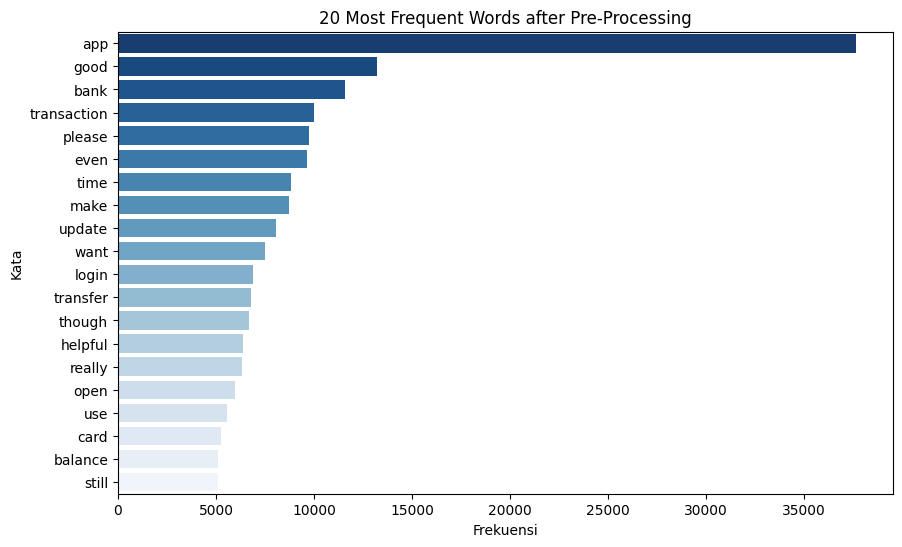

In [18]:
import seaborn as sns
from collections import Counter
import matplotlib.pyplot as plt

all_tokens = [word for tokens in df['tokens'] for word in tokens]
word_freq = Counter(all_tokens).most_common(20)

freq_df = pd.DataFrame(word_freq, columns=['Kata', 'Frekuensi'])
plt.figure(figsize=(10,6))
sns.barplot(y='Kata', x='Frekuensi', data=freq_df, palette='Blues_r')
plt.title("20 Most Frequent Words after Pre-Processing")
plt.xlabel("Frekuensi")
plt.ylabel("Kata")
plt.show()

In [19]:
print("Number of rows after pre-processing:", len(df))
df

Number of rows after pre-processing: 96200


,at,content,content_translated,cleaned,tokens
0,2025-09-21 04:02:38,sangat ok aplikasi ini,this application is very good,this app is very good,"[app, good]"
1,2025-09-21 03:31:28,mandiri yg terbaik,the best independent,the best bank,"[best, bank]"
2,2025-09-21 03:24:19,aplikasi lemot dan ribet,the application is slow and complicated,the app is slow and complicated,"[app, slow, complicated]"
3,2025-09-21 03:16:41,"Semoga lebih di permudah,sukses terus livin","Hopefully it will be easier, continued success...",hopefully it will be easier continued success app,"[hopefully, easier, app]"
4,2025-09-21 03:14:06,sedih bgt kl sering minta update. hp mekori su...,It's really sad when you frequently ask for up...,it is really sad when you frequently ask for u...,"[really, sad, frequently, ask, update, mekori,..."
...,...,...,...,...,...
96195,2023-08-21 05:43:31,Mantap 👍,Great 👍,great,[great]
96196,2023-08-21 05:40:08,(Pppp(kokolaverz koll lkklkkl klip kkkkkklkkk,(Pppp(kokolaverz koll lkklkkl klip kkkkkklkkk,pppp kokolaverz koll lkklkkl klip kkkkkklkkk,"[pppp, kokolaverz, koll, lkklkkl, klip, kkkkkk..."
96197,2023-08-21 05:37:51,Mantap,Excellent,excellent,[excellent]
96198,2023-08-21 05:37:45,Kepana sekarang mau transfer gagal terus,Why do transfers keep failing now?,why do transfers keep failing now,"[transfer, keep, failing]"


# **Transformation**

## **Topic Modeling (LDA)**

In [20]:
pip install gensim

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
from gensim import corpora
from gensim.models.ldamodel import LdaModel
from gensim.models import CoherenceModel
from pprint import pprint
import ast

### **Finding the Optimal Number of Topics Based on the Coherence Score**

In [22]:
def ensure_list(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return x.split()  
    elif isinstance(x, list):
        return x
    else:
        return []
    
texts = df['tokens'].dropna().apply(ensure_list).tolist()

In [23]:
dictionary = corpora.Dictionary(texts)

dictionary.filter_extremes(no_below=50, no_above=0.3) 

corpus = [dictionary.doc2bow(text) for text in texts]

In [24]:
def compute_coherence_values(dictionary, corpus, texts, start, limit, step):
    coherence_values = []
    model_list = []
    
    for num_topics in range(start, limit, step):
        model = LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=num_topics,
            random_state=100,
            update_every=1,
            chunksize=1000,
            passes=15,
            alpha='auto',
            per_word_topics=True
        )
        model_list.append(model)
        coherencemodel = CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence='c_v')
        coherence_values.append(coherencemodel.get_coherence())
        print(f"Number of topics = {num_topics}, Coherence = {coherencemodel.get_coherence():.4f}")
    
    return model_list, coherence_values

In [51]:
start, limit, step = 2, 11, 1  
model_list, coherence_values = compute_coherence_values(dictionary, corpus, texts, start, limit, step)

Number of topics = 2, Coherence = 0.5053
Number of topics = 3, Coherence = 0.5509
Number of topics = 4, Coherence = 0.5457
Number of topics = 5, Coherence = 0.5303
Number of topics = 6, Coherence = 0.5087
Number of topics = 7, Coherence = 0.5036
Number of topics = 8, Coherence = 0.5030
Number of topics = 9, Coherence = 0.4966
Number of topics = 10, Coherence = 0.4923


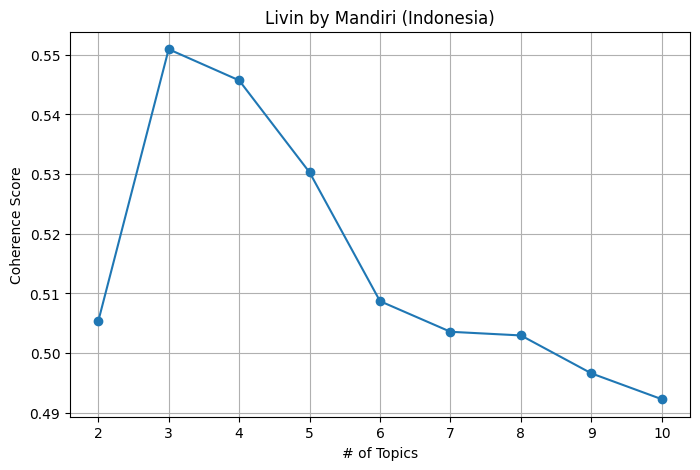

In [52]:
x = range(start, limit, step)
plt.figure(figsize=(8, 5))
plt.plot(x, coherence_values, marker='o')
plt.title('Livin by Mandiri (Indonesia)')
plt.xlabel('# of Topics')
plt.ylabel('Coherence Score')
plt.grid(True)
plt.show()

For Livin' by Mandiri (Indonesia), it was found that the ideal number of topics is 3

### **Train the LDA model using the optimal number of topics**

In [25]:
num_topics = 3
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=num_topics,
    random_state=100,
    update_every=1,
    chunksize=1000,
    passes=15,
    alpha='auto',
    per_word_topics=True
)

In [26]:
threshold = 0.35

dominant_topics = []
topic_scores = []

for bow in corpus:
    topic_probabilities = lda_model.get_document_topics(bow, minimum_probability=0)
    topic_probabilities = sorted(topic_probabilities, key=lambda x: x[1], reverse=True)

    top_topic, top_score = topic_probabilities[0]

    if top_score < threshold:
        dominant_topics.append(None)
        topic_scores.append(top_score)
    else:
        dominant_topics.append(top_topic)
        topic_scores.append(top_score)

df["lda_topic"] = dominant_topics
df["lda_topic_score"] = topic_scores

print(df["lda_topic"].value_counts(dropna=False))



lda_topic
0.0    45567
2.0    30842
1.0    19729
NaN       62
Name: count, dtype: int64


C:\Users\A.ANGGADIPA\AppData\Local\Temp\ipykernel_9660\1708725575.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["lda_topic"] = dominant_topics
C:\Users\A.ANGGADIPA\AppData\Local\Temp\ipykernel_9660\1708725575.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["lda_topic_score"] = topic_scores


In [27]:
pprint(lda_model.print_topics())

[(0,
  '0.043*"update" + 0.042*"transfer" + 0.038*"even" + 0.029*"please" + '
  '0.029*"time" + 0.027*"want" + 0.026*"though" + 0.024*"open" + '
  '0.021*"always" + 0.018*"still"'),
 (1,
  '0.124*"transaction" + 0.094*"make" + 0.092*"helpful" + 0.056*"easy" + '
  '0.038*"thank" + 0.036*"great" + 0.036*"excellent" + 0.034*"easier" + '
  '0.025*"loan" + 0.021*"feature"'),
 (2,
  '0.076*"good" + 0.055*"bank" + 0.036*"balance" + 0.023*"card" + '
  '0.019*"account" + 0.017*"help" + 0.016*"money" + 0.014*"service" + '
  '0.014*"please" + 0.013*"using"')]


**Intertopic Distance Map Visualization**

In [28]:
pip install pyLDAvis

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
import pyLDAvis
import pyLDAvis.gensim

pyLDAvis.enable_notebook()
lda_display = pyLDAvis.gensim.prepare(lda_model, corpus, dictionary, sort_topics=False)
pyLDAvis.display(lda_display)

The three topics identified for Livin’ by Mandiri are located in different quadrants with no overlap, indicating a clear distinction between the identified aspects. 

In [30]:
df.isnull().sum()

at                     0
content                0
content_translated     0
cleaned                0
tokens                 0
lda_topic             62
lda_topic_score        0
dtype: int64

In [31]:
df[["content_translated", "cleaned", "tokens", "lda_topic", "lda_topic_score"]]

,content_translated,cleaned,tokens,lda_topic,lda_topic_score
0,this application is very good,this app is very good,"[app, good]",2.0,0.502117
1,the best independent,the best bank,"[best, bank]",2.0,0.402481
2,the application is slow and complicated,the app is slow and complicated,"[app, slow, complicated]",0.0,0.466103
3,"Hopefully it will be easier, continued success...",hopefully it will be easier continued success app,"[hopefully, easier, app]",1.0,0.528300
4,It's really sad when you frequently ask for up...,it is really sad when you frequently ask for u...,"[really, sad, frequently, ask, update, mekori,...",0.0,0.795688
...,...,...,...,...,...
96195,Great 👍,great,[great],1.0,0.411525
96196,(Pppp(kokolaverz koll lkklkkl klip kkkkkklkkk,pppp kokolaverz koll lkklkkl klip kkkkkklkkk,"[pppp, kokolaverz, koll, lkklkkl, klip, kkkkkk...",0.0,0.443799
96197,Excellent,excellent,[excellent],1.0,0.411525
96198,Why do transfers keep failing now?,why do transfers keep failing now,"[transfer, keep, failing]",0.0,0.720081


## **Aspect Extraction**

**Topic Labeling**

In [32]:
topic_labels = {
    0: "access",
    1: "usability",
    2: "account"
}

df["aspect"] = df["lda_topic"].map(topic_labels)
df["aspect"] = df["aspect"].fillna("unknown")
df[["content_translated", "cleaned", "tokens", "aspect"]]


C:\Users\A.ANGGADIPA\AppData\Local\Temp\ipykernel_9660\3275960449.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["aspect"] = df["lda_topic"].map(topic_labels)
C:\Users\A.ANGGADIPA\AppData\Local\Temp\ipykernel_9660\3275960449.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["aspect"] = df["aspect"].fillna("unknown")


,content_translated,cleaned,tokens,aspect
0,this application is very good,this app is very good,"[app, good]",account
1,the best independent,the best bank,"[best, bank]",account
2,the application is slow and complicated,the app is slow and complicated,"[app, slow, complicated]",access
3,"Hopefully it will be easier, continued success...",hopefully it will be easier continued success app,"[hopefully, easier, app]",usability
4,It's really sad when you frequently ask for up...,it is really sad when you frequently ask for u...,"[really, sad, frequently, ask, update, mekori,...",access
...,...,...,...,...
96195,Great 👍,great,[great],usability
96196,(Pppp(kokolaverz koll lkklkkl klip kkkkkklkkk,pppp kokolaverz koll lkklkkl klip kkkkkklkkk,"[pppp, kokolaverz, koll, lkklkkl, klip, kkkkkk...",access
96197,Excellent,excellent,[excellent],usability
96198,Why do transfers keep failing now?,why do transfers keep failing now,"[transfer, keep, failing]",access


**Visualization of Review Distribution by Aspect**

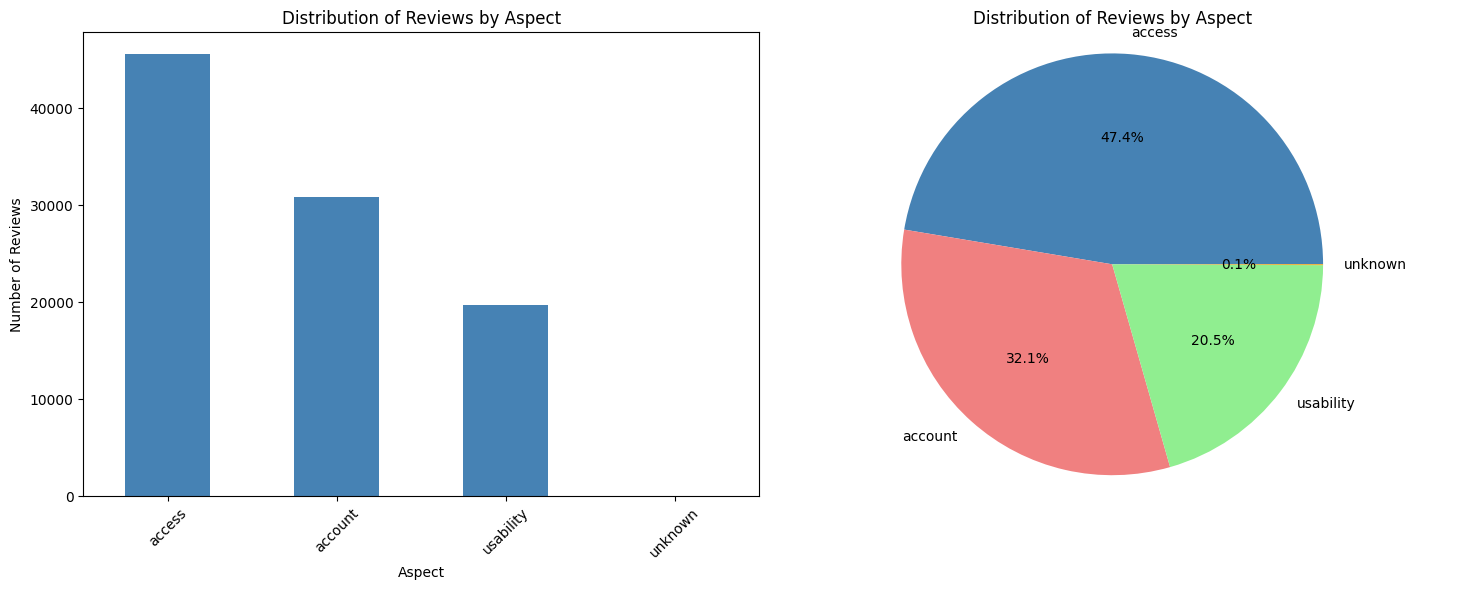

In [33]:
plt.figure(figsize=(15, 6))

# Histogram
plt.subplot(1, 2, 1)
df["aspect"].value_counts().plot(kind="bar", color="steelblue")
plt.title("Distribution of Reviews by Aspect")
plt.xlabel("Aspect")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)

# Pie Chart
plt.subplot(1, 2, 2)
aspect_counts = df["aspect"].value_counts()
plt.pie(aspect_counts, labels=aspect_counts.index, autopct='%1.1f%%', 
    colors=['steelblue', 'lightcoral', 'lightgreen', 'orange', 'lightgray'])
plt.title("Distribution of Reviews by Aspect")
plt.axis('equal')

plt.tight_layout()
plt.show()

# **Data Mining**

## **VADER Sentiment Labeling**

In [34]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\A.ANGGADIPA\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [35]:
def get_sentiment_label(text):
    score = sia.polarity_scores(text)
    compound = score['compound']
    if compound >= 0.05:
        return "positive"
    elif compound <= -0.05:
        return "negative"
    else:
        return "neutral"

In [36]:
df["sentiment"] = df["cleaned"].apply(get_sentiment_label)

df[["content_translated", "cleaned", "tokens", "sentiment", "aspect"]]

C:\Users\A.ANGGADIPA\AppData\Local\Temp\ipykernel_9660\2825488844.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["sentiment"] = df["cleaned"].apply(get_sentiment_label)


,content_translated,cleaned,tokens,sentiment,aspect
0,this application is very good,this app is very good,"[app, good]",positive,account
1,the best independent,the best bank,"[best, bank]",positive,account
2,the application is slow and complicated,the app is slow and complicated,"[app, slow, complicated]",neutral,access
3,"Hopefully it will be easier, continued success...",hopefully it will be easier continued success app,"[hopefully, easier, app]",positive,usability
4,It's really sad when you frequently ask for up...,it is really sad when you frequently ask for u...,"[really, sad, frequently, ask, update, mekori,...",positive,access
...,...,...,...,...,...
96195,Great 👍,great,[great],positive,usability
96196,(Pppp(kokolaverz koll lkklkkl klip kkkkkklkkk,pppp kokolaverz koll lkklkkl klip kkkkkklkkk,"[pppp, kokolaverz, koll, lkklkkl, klip, kkkkkk...",neutral,access
96197,Excellent,excellent,[excellent],positive,usability
96198,Why do transfers keep failing now?,why do transfers keep failing now,"[transfer, keep, failing]",negative,access


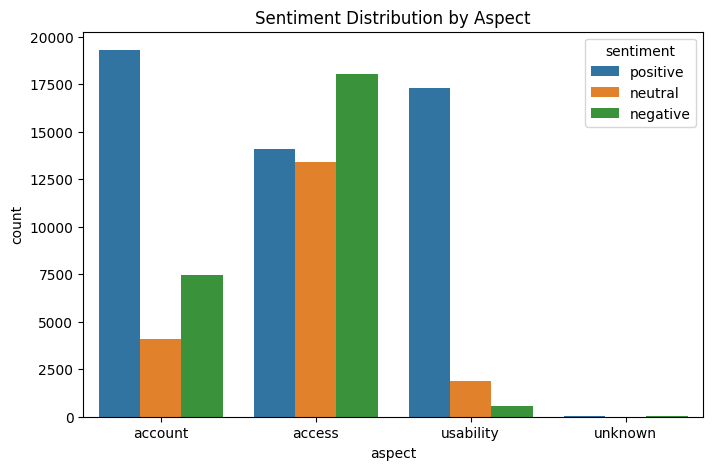

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="aspect", hue="sentiment")
plt.title("Sentiment Distribution by Aspect")
plt.show()


In [38]:
df["sentiment"].value_counts()

sentiment
positive    50694
negative    26128
neutral     19378
Name: count, dtype: int64

In [39]:
# Percentage
df["sentiment"].value_counts(normalize=True).round(3)

sentiment
positive    0.527
negative    0.272
neutral     0.201
Name: proportion, dtype: float64

In [40]:
df = df[df["aspect"] != "unknown"]
print("Number of rows in the dataset after the unknown aspect is excluded:", len(df))

Number of rows in the dataset after the unknown aspect is excluded: 96138


Neutral reviews were excluded from the dataset because they often contain ambiguous feedback that lacks strong emotional polarization, making it difficult to identify clear problem areas or satisfaction factors.

In [41]:
df = df[df["sentiment"] != "neutral"]
print("Number of rows in the dataset after neutral sentiment has been excluded:", len(df))

Number of rows in the dataset after neutral sentiment has been excluded: 76767


## **Application of the Classification Model to the Entire Dataset**

**TF-IDF & Split Dataset**

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

X = df['cleaned']
y = df['sentiment']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

In [44]:
tfidf = TfidfVectorizer(max_features=5000) 
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

**Support Vector Machine (SVM)**

In [45]:
from sklearn.svm import SVC

svm_model = SVC(kernel='linear', random_state=42)

svm_model.fit(X_train_tfidf, y_train)

SVC(kernel='linear', random_state=42)

In [46]:
y_pred = svm_model.predict(X_test_tfidf)

**Confusion Matrix Evaluation**

In [47]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

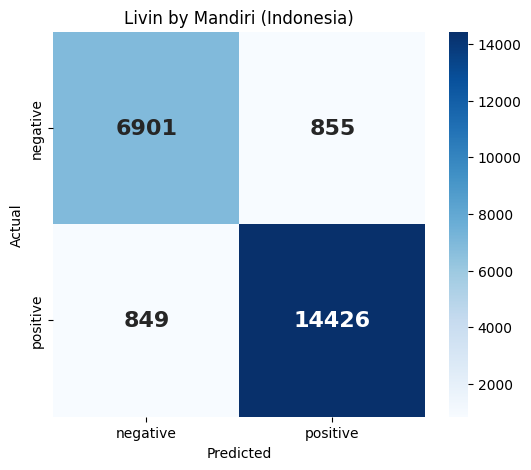

In [48]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_,
            annot_kws={"size":16, "weight":"bold"})
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Livin by Mandiri (Indonesia)')
plt.show()

**Classification Report**

In [49]:
from sklearn.metrics import classification_report

classification_report(y_test, y_pred, target_names=le.classes_, digits=4)

'              precision    recall  f1-score   support\n\n    negative     0.8905    0.8898    0.8901      7756\n    positive     0.9440    0.9444    0.9442     15275\n\n    accuracy                         0.9260     23031\n   macro avg     0.9172    0.9171    0.9172     23031\nweighted avg     0.9260    0.9260    0.9260     23031\n'

**ROC-AUC Evaluation**

In [50]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

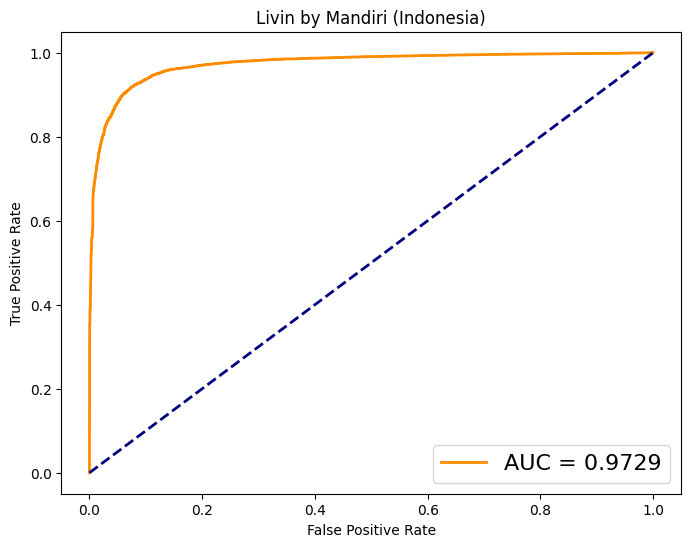

In [51]:
y_score = svm_model.decision_function(X_test_tfidf)

fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Livin by Mandiri (Indonesia)')
plt.legend(loc="lower right", fontsize=16)
plt.show()

## **Application of the Classification Model to Each Aspect**

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

In [53]:
def svm_each_aspect(df):
    results = []
    
    df_bin = df[df['sentiment'].str.lower().isin(['positive', 'negative'])].copy()
    unique_aspects = df_bin['aspect'].dropna().unique()
    
    cm_data = {}
    roc_data = {}
    le_classes = {}
    
    for aspect in unique_aspects:
        df_subset = df_bin[df_bin['aspect'] == aspect].copy()
        
        X = df_subset['cleaned']
        y = df_subset['sentiment'].str.lower() 
        
        # TF-IDF & Split Dataset
        le = LabelEncoder()
        y_encoded = le.fit_transform(y)
            
        X_train, X_test, y_train, y_test = train_test_split(
            X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
        )
        
        tfidf = TfidfVectorizer(max_features=5000)
        X_train_tfidf = tfidf.fit_transform(X_train)
        X_test_tfidf = tfidf.transform(X_test)
        
        # SVM Modeling
        svm_model = SVC(kernel='linear', random_state=42)
        svm_model.fit(X_train_tfidf, y_train)
        
        y_pred = svm_model.predict(X_test_tfidf)
        y_score = svm_model.decision_function(X_test_tfidf)
        
        # Evaluation
        acc = accuracy_score(y_test, y_pred)
        report = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)
        acc_str = f"{acc * 100:.2f}%"
        
        if 'positive' in report:
            results.append({
                'Aspect': aspect.title(),
                'Sentiment': 'Positive',
                'Precision': round(report['positive']['precision'], 4),
                'Recall': round(report['positive']['recall'], 4),
                'F1-Score': round(report['positive']['f1-score'], 4),
                'Accuracy': acc_str
            })
            
        if 'negative' in report:
            results.append({
                'Aspect': aspect.title(),
                'Sentiment': 'Negative',
                'Precision': round(report['negative']['precision'], 4),
                'Recall': round(report['negative']['recall'], 4),
                'F1-Score': round(report['negative']['f1-score'], 4),
                'Accuracy': acc_str
            })
            
        cm_data[aspect] = confusion_matrix(y_test, y_pred)
        le_classes[aspect] = le.classes_
        
        fpr, tpr, _ = roc_curve(y_test, y_score)
        roc_data[aspect] = (fpr, tpr, auc(fpr, tpr))
            
    df_results = pd.DataFrame(results)
    df_display = df_results.copy()
    
    df_display.loc[df_display.duplicated('Aspect'), ['Aspect', 'Accuracy']] = ''
    
    display(df_display)

    num_aspects = len(cm_data)
    cols = 3 
    rows = math.ceil(num_aspects / cols)
    
    fig_cm, axes_cm = plt.subplots(rows, cols, figsize=(16, 5 * rows))
    
    if num_aspects > 1:
        axes_cm = axes_cm.flatten()
    else:
        axes_cm = [axes_cm]
    
    for idx, (aspect, cm) in enumerate(cm_data.items()):
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_cm[idx],
                    xticklabels=le_classes[aspect], yticklabels=le_classes[aspect],
                    annot_kws={"size": 16, "weight": "bold"})
        axes_cm[idx].set_title(f'Aspect: {aspect.title()}', fontweight='bold', fontsize=12)
        axes_cm[idx].set_xlabel('Predicted', fontsize=12)
        axes_cm[idx].set_ylabel('Actual', fontsize=12)
        
    for i in range(num_aspects, len(axes_cm)):
        fig_cm.delaxes(axes_cm[i])
        
    plt.tight_layout()
    plt.show()
    
    plt.figure(figsize=(10, 8))
    colors = plt.cm.get_cmap('tab10', len(roc_data))
    
    for idx, (aspect, (fpr, tpr, roc_auc)) in enumerate(roc_data.items()):
        plt.plot(fpr, tpr, lw=2, color=colors(idx), 
                 label=f'{aspect.title()} (AUC = {roc_auc:.4f})')
        
    plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'ROC Curve per Aspect', fontsize=16)
    plt.legend(loc="lower right", fontsize=16)
    plt.grid(True, alpha=0.3)
    plt.show()

,Aspect,Sentiment,Precision,Recall,F1-Score,Accuracy
0,Account,Positive,0.9384,0.9394,0.9389,91.18%
1,,Negative,0.8429,0.8406,0.8418,
2,Usability,Positive,0.9919,0.9971,0.9945,98.94%
3,,Negative,0.8973,0.7572,0.8213,
4,Access,Positive,0.8859,0.8750,0.8804,89.59%
5,,Negative,0.9035,0.9122,0.9078,


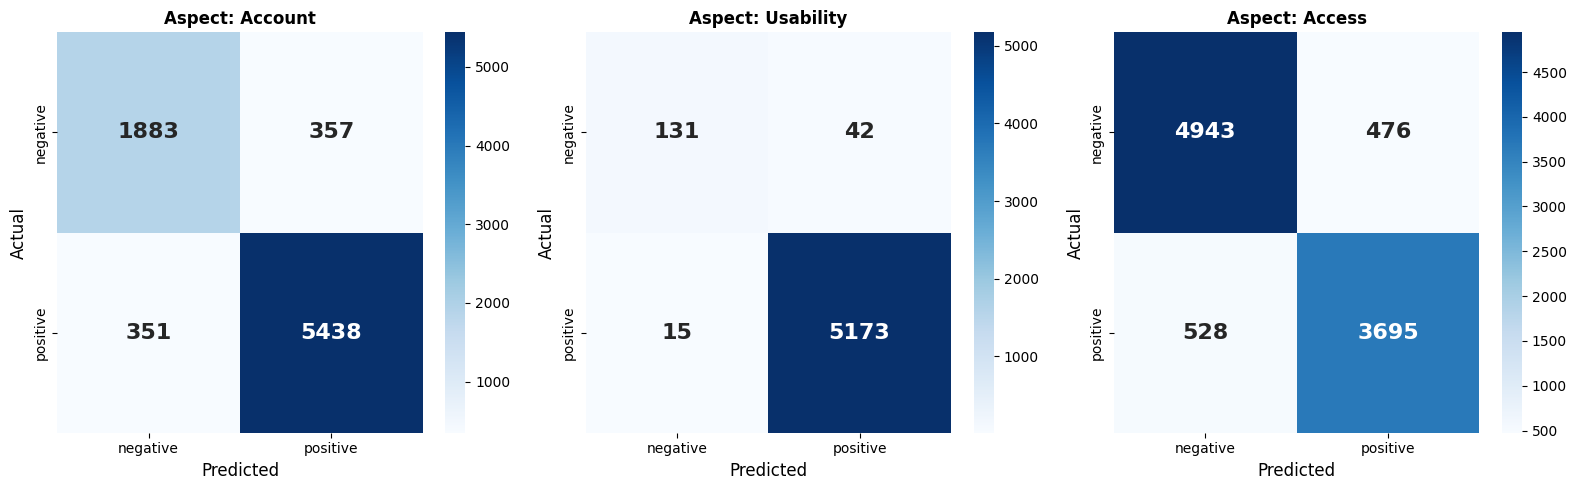

C:\Users\A.ANGGADIPA\AppData\Local\Temp\ipykernel_9660\1585895610.py:100: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(roc_data))


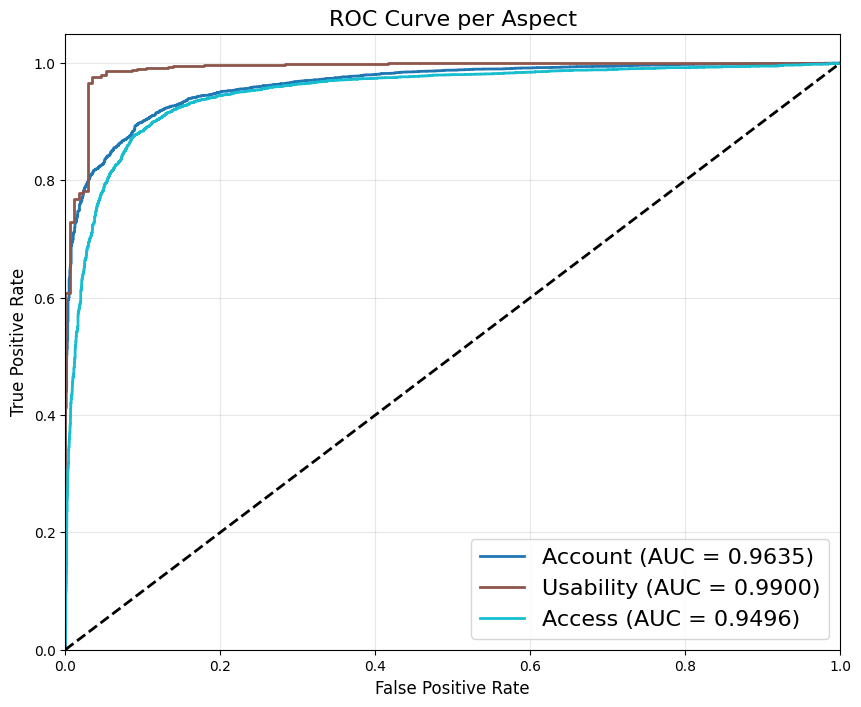

In [54]:
results = svm_each_aspect(df)
results

As a note regarding the evaluation results for this aspect, no data balancing (resampling) techniques were used in this study. This decision was based on two grounds. First, from an algorithmic perspective, referring to the findings of Basri et al. (2026), the application of resampling (such as SMOTE) to SVM models actually risks distorting the distribution of the minority class and compromising the accuracy of the model’s hyperplane, which could ultimately reduce classification performance. Second, from a methodological perspective, maintaining the data distribution in its original proportions is crucial because this study is oriented toward extracting insights and understanding user behavior patterns. As supported by the research of Zafira et al. (2025), allowing the imbalance in review data to remain natural is an essential step for capturing field realities proportionally in order to gain strategic insights.

Basri, H., Purwanti, W. N., & Alparisi, I. (2026). Evaluating SMOTE Performance for Imbalanced Multi-Label Sentiment Classification in MLSE Usability Testing of Mobile App Reviews. Jurnal Teknik Informatika (Jutif), 7(2), 937–947. https://doi.org/10.52436/1.jutif.2026.7.2.5351

Zafira, Z. T., Tania, K. D., & Sari, W. K. (2025). Sentiment-Based Knowledge Discovery of Wondr by BNI App Reviews Using SVM, KNN, and Naive Bayes for CRM Enhancement. Journal of Applied Informatics and Computing (JAIC), 9(5), 2498–2508. http://jurnal.polibatam.ac.id/index.php/JAIC